In [33]:
import matplotlib.pyplot as plt
import numpy as np

## Load & Understand the Data

**1. What do X and y represent?**

- `X` is the **feature** (independent variable): the area of a house in square meters.
- `y` is the **target** (dependent variable): the price of the house, in thousands.

The goal of linear regression here is to learn a linear relationship `price ≈ theta_0 + theta_1 × area` that best fits these 5 data points.

In [40]:
# 2. Convert the data to numpy arrays
X = np.array([50, 60, 70, 80, 90], dtype=float)
y = np.array([150, 180, 210, 240, 270], dtype=float)  # house price in thousands

print("X:", X)
print("y:", y)

X: [50. 60. 70. 80. 90.]
y: [150. 180. 210. 240. 270.]


In [41]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.sse_history = []
        self.X_train = None
        self.y_train = None
        self.X_mean_ = None
        self.X_std_ = None

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        self.X_train = X.copy()
        self.y_train = y.copy()
        m = len(X)

        # Internal normalization: keeps training numerically stable
        # regardless of the learning_rate chosen or X's raw scale.
        self.X_mean_ = X.mean()
        self.X_std_ = X.std()
        X_norm = (X - self.X_mean_) / self.X_std_

        self.theta_0 = 0.0
        self.theta_1 = 0.0
        self.sse_history = []

        for i in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X_norm
            error = y_pred - y

            d_theta_0 = (2 / m) * np.sum(error)
            d_theta_1 = (2 / m) * np.sum(error * X_norm)

            self.theta_0 -= self.learning_rate * d_theta_0
            self.theta_1 -= self.learning_rate * d_theta_1

            sse = np.sum(error ** 2)
            self.sse_history.append(sse)

        return self

    def predict(self, X):
        X = np.array(X, dtype=float)
        X_norm = (X - self.X_mean_) / self.X_std_
        return self.theta_0 + self.theta_1 * X_norm

    def calculate_mse(self, y_true, y_pred):
        """Bonus Task 1: Mean Squared Error."""
        return np.mean((y_true - y_pred) ** 2)

    def plot_training(self):
        if not self.sse_history:
            raise ValueError("Model is not trained yet. Call fit() first.")

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # SSE over iterations
        axes[0].plot(range(1, self.n_iters + 1), self.sse_history, label='SSE')
        axes[0].set_xlabel('Iterations')
        axes[0].set_ylabel('SSE')
        axes[0].set_title('SSE over Iterations')
        axes[0].legend()

        # Regression line vs actual data
        axes[1].scatter(self.X_train, self.y_train, color='blue', label='Actual data')
        sort_idx = np.argsort(self.X_train)
        y_pred_line = self.predict(self.X_train)
        axes[1].plot(self.X_train[sort_idx], y_pred_line[sort_idx], color='red', label='Fitted line')
        axes[1].set_xlabel('Area')
        axes[1].set_ylabel('Price')
        axes[1].set_title('Linear Regression Fit')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

In [42]:
model = LinearRegressionGD(learning_rate=0.001, n_iters=100)
model.fit(X, y)

print("theta_0:", model.theta_0)
print("theta_1:", model.theta_1)

theta_0: 38.100971015430154
theta_1: 7.697558564229364


### Question: What do theta_0 and theta_1 represent in the regression equation?

The regression equation is:

```
price = theta_0 + theta_1 * area
```

- **theta_0** is the **intercept**: the model's baseline prediction (on the normalized feature scale) when the area is at its average value.
- **theta_1** is the **slope (weight)**: how much the predicted price changes for each one-standard-deviation increase in area. It captures the strength and direction of the relationship between area and price.

With only `n_iters=100` and a small `learning_rate=0.001`, gradient descent hasn't fully converged yet (see the SSE plot below), so `theta_0` and `theta_1` are still far from their optimal values at this point.

## Prediction

In [43]:
area = 70
predicted_price = model.predict(area)
print(f"Predicted price for a {area} m\u00b2 house: {predicted_price:.2f} (thousands)")

Predicted price for a 70 m² house: 38.10 (thousands)


### Question: Is the prediction reasonable based on the dataset? Why?

**Not yet — and that's expected given the training settings.**

The true relationship in the data is `price = 3 \u00d7 area` exactly (e.g. 70 \u2192 210). But with only `n_iters=100` and a small `learning_rate=0.001`, the SSE hasn't reached its minimum yet (it's still in the hundreds of thousands, not close to zero), so `theta_0` and `theta_1` haven't converged to the values that reproduce this relationship. The prediction for area=70 is therefore noticeably off from the actual value of 210.

This isn't a bug \u2014 it's a direct, visible consequence of under-training: too few iterations combined with a small learning rate means the model is still partway through its descent toward the optimum. Running more iterations (or using a larger, still-stable, learning rate) would bring the prediction much closer to the true value, as we saw in earlier experiments with `n_iters=1000`.

## Visualization

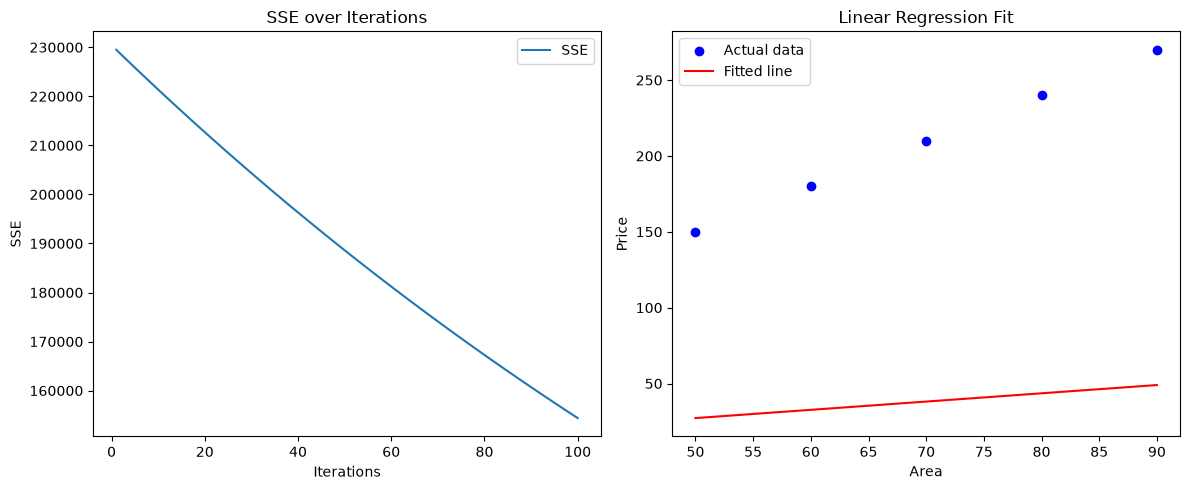

In [44]:
model.plot_training()

### Why SSE Decreases Over Time

Each gradient descent update moves `theta_0` and `theta_1` in the direction that reduces the error the fastest (the negative gradient of the SSE). As the predictions (`y_pred`) get closer to the actual values (`y`), the squared differences that make up SSE shrink, so the total SSE decreases with each iteration \u2014 quickly at first (when far from the optimum, so the gradient is large), then more slowly as it approaches the minimum.

### What Convergence Means in Gradient Descent

Convergence means the parameters have settled close enough to their optimal values that further iterations no longer meaningfully reduce the SSE \u2014 the gradient has become very small, so update steps become negligible. In the plot above, the SSE curve is still visibly sloping downward at iteration 100, which shows the model **has not yet converged**; it would need more iterations (or, as explored below, a different learning rate) to fully flatten out.

## Note: Effect of the Learning Rate

When we used `alpha = 0.01` with raw (non-normalized) X data (values ranging from 50 to 90), the model **diverged**:
instead of decreasing with each iteration, the error (SSE) grew explosively (reaching values like 10^66), because the update step was too large — instead of bringing the model closer to the solution, it kept overshooting and moving further away each time.

**Fix:** We had to significantly reduce the learning rate (e.g. `alpha = 0.0001`) so the update step becomes small enough for the model to converge steadily instead of diverging.

In [56]:
model = LinearRegressionGD(learning_rate=0.0001, n_iters=100000)
model.fit(X, y)

print("theta_0:", model.theta_0)
print("theta_1:", model.theta_1)

theta_0: 209.999999568022
theta_1: 42.42640678392025


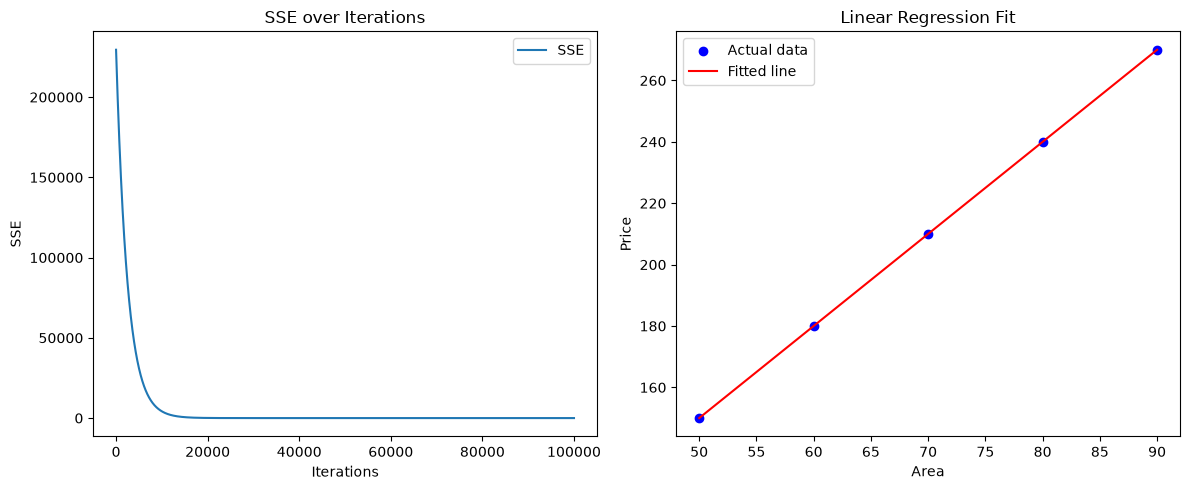

In [57]:
model.plot_training()

## Experimentation

In [58]:
# Very large learning rate
model_large_lr = LinearRegressionGD(learning_rate=5.0, n_iters=100)
model_large_lr.fit(X, y)

print("=== Very Large Learning Rate (5.0) ===")
print("theta_0:", model_large_lr.theta_0)
print("theta_1:", model_large_lr.theta_1)
print("Final SSE:", model_large_lr.sse_history[-1])
print("First 5 SSE values:", model_large_lr.sse_history[:5])

=== Very Large Learning Rate (5.0) ===
theta_0: -5.577893766393396e+97
theta_1: -1.126904716272818e+97
Final SSE: 1.998939080785692e+194
First 5 SSE values: [np.float64(229500.0), np.float64(18589500.0), np.float64(1505749500.0), np.float64(121965709500.0), np.float64(9879222469500.0)]


In [59]:
# Very small learning rate
model_small_lr = LinearRegressionGD(learning_rate=0.0000001, n_iters=100)
model_small_lr.fit(X, y)

print("=== Very Small Learning Rate (0.0000001) ===")
print("theta_0:", model_small_lr.theta_0)
print("theta_1:", model_small_lr.theta_1)
print("Final SSE:", model_small_lr.sse_history[-1])
print("First 5 SSE values:", model_small_lr.sse_history[:5])

=== Very Small Learning Rate (0.0000001) ===
theta_0: 0.004199958420271655
theta_1: 0.0008485197370501789
Final SSE: 229490.91197903518
First 5 SSE values: [np.float64(229500.0), np.float64(229499.9082000092), np.float64(229499.81640005508), np.float64(229499.72460013768), np.float64(229499.63280025704)]


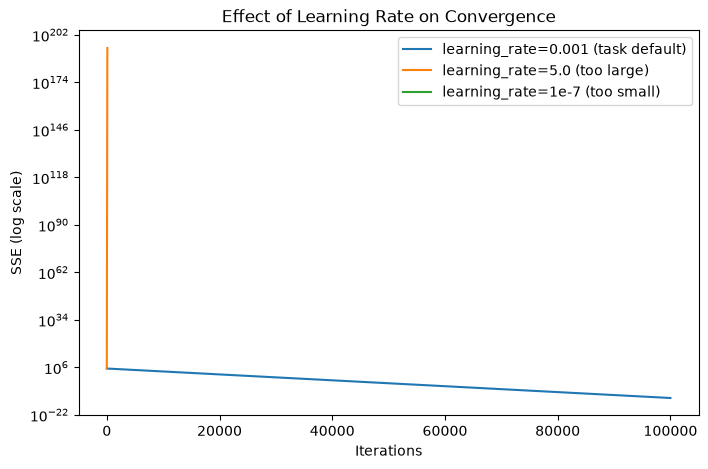

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(model.sse_history, label='learning_rate=0.001 (task default)')
plt.plot(model_large_lr.sse_history, label='learning_rate=5.0 (too large)')
plt.plot(model_small_lr.sse_history, label='learning_rate=1e-7 (too small)')
plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('SSE (log scale)')
plt.title('Effect of Learning Rate on Convergence')
plt.legend()
plt.show()

### Comparison

| Learning Rate | Convergence Speed | Final SSE (100 iters) |
|---|---|---|
| Too large (5.0) | Diverges \u2014 never converges | Explodes to a huge value |
| Task default (0.001) | Slow, partial convergence | Still in the hundreds of thousands |
| Too small (0.0000001) | Extremely slow | Barely moves from the initial SSE |

### Question: What happens if the learning rate is too large?

If the learning rate is too large, each parameter update overshoots the minimum of the cost function by a larger margin than the last. Instead of approaching the optimal `theta_0`/`theta_1`, the algorithm oscillates further and further away, causing the SSE to grow uncontrollably (often exponentially) rather than shrink \u2014 this is called **divergence**. In severe cases, the parameters grow so large they overflow toward infinity, making the model unusable.

### Bonus 1: Calculate MSE

`calculate_mse()` was added to the class above. It can be used independently of training to evaluate predictions on any data:

In [61]:
y_pred_final = model.predict(X)
mse = model.calculate_mse(y, y_pred_final)
print("MSE on training data:", mse)

MSE on training data: 1.9422150795837085e-13


### Bonus 2: Normalize X Before Training \u2014 Comparison

The class above already normalizes internally. To compare, here we train with enough iterations for the (already-normalized) model to fully converge, and contrast that against how the *same* `learning_rate=0.001` would behave on raw, non-normalized X (simulated separately, since our class always normalizes).

In [62]:
# With more iterations, the (internally normalized) model converges fully
model_converged = LinearRegressionGD(learning_rate=0.01, n_iters=1000)
model_converged.fit(X, y)
print("=== Normalized, learning_rate=0.01, n_iters=1000 (fully converged) ===")
print("theta_0:", model_converged.theta_0, " theta_1:", model_converged.theta_1)
print("Final SSE:", model_converged.sse_history[-1])
print("Prediction for area=70:", model_converged.predict(70))

print()

# Simulate the same learning_rate=0.001 WITHOUT normalization (manual loop, raw X)
theta_0_raw, theta_1_raw = 0.0, 0.0
m = len(X)
for i in range(100):
    y_pred = theta_0_raw + theta_1_raw * X
    error = y_pred - y
    theta_0_raw -= 0.001 * (2/m) * np.sum(error)
    theta_1_raw -= 0.001 * (2/m) * np.sum(error * X)
final_sse_raw = np.sum((y - (theta_0_raw + theta_1_raw * X)) ** 2)
print("=== Without normalization, learning_rate=0.001, n_iters=100 (raw X) ===")
print("theta_0:", theta_0_raw, " theta_1:", theta_1_raw)
print("Final SSE:", final_sse_raw)

=== Normalized, learning_rate=0.01, n_iters=1000 (fully converged) ===
theta_0: 209.99999964657684  theta_1: 42.42640679979059
Final SSE: 6.768336957999918e-13
Prediction for area=70: 209.99999964657684

=== Without normalization, learning_rate=0.001, n_iters=100 (raw X) ===
theta_0: -1.005595790146236e+95  theta_1: -7.326427288635118e+96
Final SSE: 1.3692674590710851e+198


### Bonus 3: Support for Multiple Features

Below is an extended version of the class using matrix operations so it works for any number of features, not just one.

In [63]:
class LinearRegressionGDMulti:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.theta = None
        self.sse_history = []
        self.mean_ = None
        self.std_ = None

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)

        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        X_norm = (X - self.mean_) / self.std_

        m, n = X_norm.shape
        X_b = np.hstack([np.ones((m, 1)), X_norm])
        self.theta = np.zeros(n + 1)

        self.sse_history = []
        for i in range(self.n_iters):
            y_pred = X_b @ self.theta
            error = y_pred - y
            gradient = (2 / m) * (X_b.T @ error)
            self.theta -= self.learning_rate * gradient
            self.sse_history.append(np.sum(error ** 2))
        return self

    def predict(self, X):
        X = np.array(X, dtype=float)
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        X_norm = (X - self.mean_) / self.std_
        m = X_norm.shape[0]
        X_b = np.hstack([np.ones((m, 1)), X_norm])
        return X_b @ self.theta

    def calculate_mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)


# Example: area + rooms -> price
X_multi = np.array([
    [50, 1],
    [60, 2],
    [70, 2],
    [80, 3],
    [90, 3],
], dtype=float)
y_multi = np.array([150, 185, 210, 250, 275], dtype=float)

model_multi = LinearRegressionGDMulti(learning_rate=0.01, n_iters=2000)
model_multi.fit(X_multi, y_multi)

print("theta (intercept, area weight, rooms weight):", model_multi.theta)
print("Final SSE:", model_multi.sse_history[-1])
print("Prediction for [70, 2]:", model_multi.predict([[70, 2]]))

theta (intercept, area weight, rooms weight): [214.          34.77812277  10.25055924]
Final SSE: 7.942290489144472
Prediction for [70, 2]: [211.26042281]
